# **Import Library**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
Earthquake = pd.read_csv("/content/Earthquake Time-Series Anomaly Detection. (1).csv")
Earthquake.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2010-12-31T23:18:12.650Z,26.617,142.937,10.0,4.1,mb,19.0,114.7,NaN,0.41,...,2014-11-07T01:43:16.958Z,"Bonin Islands, Japan region",earthquake,NaN,NaN,NaN,11.0,reviewed,us,us
1,2010-12-31T23:01:03.440Z,36.678,140.789,52.1,4.6,mwr,161.0,109.6,NaN,0.95,...,2014-11-07T01:43:16.945Z,"7 km ESE of Takahagi, Japan",earthquake,NaN,3.6,NaN,NaN,reviewed,us,nied
2,2010-12-31T22:49:31.720Z,27.284,143.401,11.9,4.3,mb,24.0,107.5,NaN,0.52,...,2014-11-07T01:43:16.943Z,"Bonin Islands, Japan region",earthquake,NaN,21.8,NaN,12.0,reviewed,us,us
3,2010-12-31T22:32:13.290Z,-24.050,-176.382,17.7,4.5,mb,17.0,87.3,NaN,0.73,...,2014-11-07T01:43:16.941Z,south of the Fiji Islands,earthquake,NaN,21.9,NaN,6.0,reviewed,us,us
4,2010-12-31T22:04:44.350Z,11.884,44.059,10.0,4.8,mb,48.0,95.0,NaN,0.72,...,2014-11-07T01:43:16.937Z,"84 km E of Obock, Djibouti",earthquake,NaN,NaN,NaN,22.0,reviewed,us,us


In [7]:
# Convert time column
Earthquake['time'] = pd.to_datetime(Earthquake['time'])

# Sort by time
Earthquake = Earthquake.sort_values('time')

# Select important features (recommended)
Earthquake = Earthquake[['time', 'latitude', 'longitude', 'depth', 'mag', 'rms']]

Earthquake.head()

,time,latitude,longitude,depth,mag,rms
17095,2010-01-01 02:08:21.900000+00:00,26.290000,99.866000,10.000,5.00,0.97
17094,2010-01-01 02:22:23.820000+00:00,30.646000,83.791000,10.000,5.20,1.09
17093,2010-01-01 02:33:42.820000+00:00,32.453833,-115.202833,5.995,3.24,0.48
17092,2010-01-01 02:34:56.050000+00:00,40.726000,51.925000,46.100,5.00,0.88
17091,2010-01-01 04:13:44.710000+00:00,42.616000,-111.058000,5.000,3.00,0.90


# **Missing Values**

In [8]:
Earthquake.isnull().sum()

,0
time,0
latitude,0
longitude,0
depth,0
mag,0
rms,3920


In [9]:
# Fill missing values
Earthquake = Earthquake.fillna(method='ffill')

/tmp/ipykernel_380/3085684824.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Earthquake = Earthquake.fillna(method='ffill')


# **Summary Statistics**

In [10]:
Earthquake.describe()

,latitude,longitude,depth,mag,rms
count,17096.000000,17096.000000,17096.000000,17096.00000,17096.000000
mean,9.556959,-10.773879,44.664396,4.25836,0.867510
std,32.798385,126.148915,78.972727,0.70504,0.347752
min,-80.732000,-179.981000,-2.600000,3.00000,0.010000
25%,-18.389000,-115.648750,10.000000,3.80000,0.730000
50%,13.857000,-70.392500,24.700000,4.30000,0.910000
75%,34.266500,128.160000,39.800000,4.70000,1.090000
max,85.398000,179.993000,643.700000,8.80000,4.730000


# **EDA**

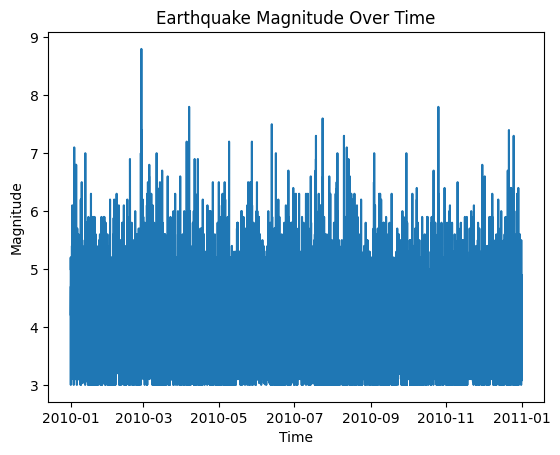

In [11]:
plt.figure()

plt.plot(Earthquake['time'], Earthquake['mag'])
plt.title("Earthquake Magnitude Over Time")
plt.xlabel("Time")
plt.ylabel("Magnitude")

plt.show()

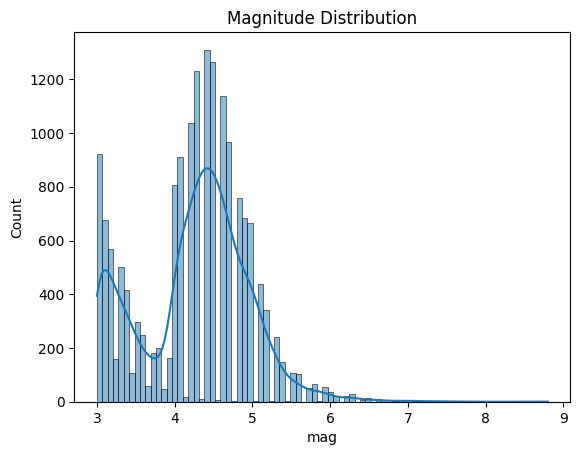

In [12]:
sns.histplot(Earthquake['mag'], kde=True)
plt.title("Magnitude Distribution")
plt.show()

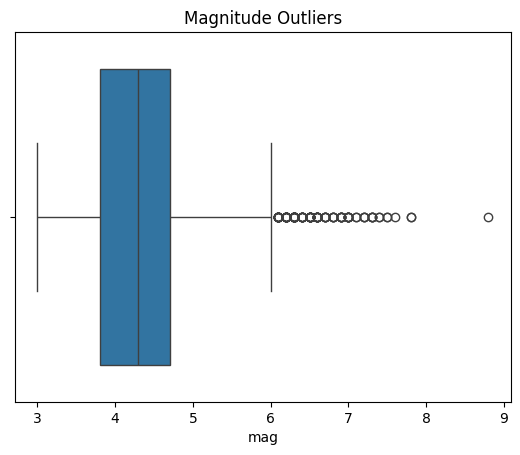

In [13]:
sns.boxplot(x=Earthquake['mag'])
plt.title("Magnitude Outliers")
plt.show()

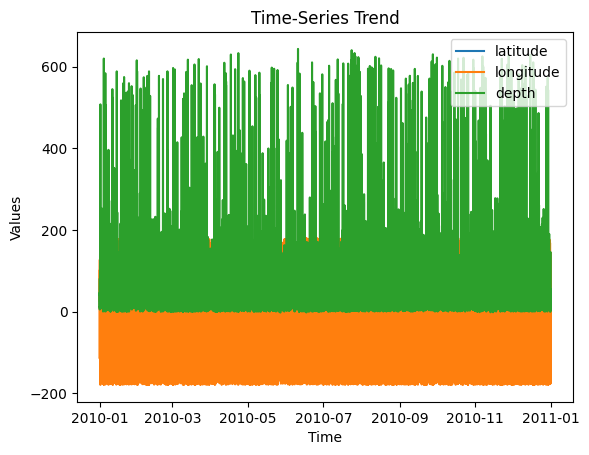

In [14]:
if 'time' in Earthquake.columns:
    Earthquake['time'] = pd.to_datetime(Earthquake['time'])
    Earthquake = Earthquake.sort_values('time')

    plt.figure()
    for col in Earthquake.select_dtypes(include=np.number).columns[:3]:
        plt.plot(Earthquake['time'], Earthquake[col], label=col)

    plt.legend()
    plt.title("Time-Series Trend")
    plt.xlabel("Time")
    plt.ylabel("Values")
    plt.show()

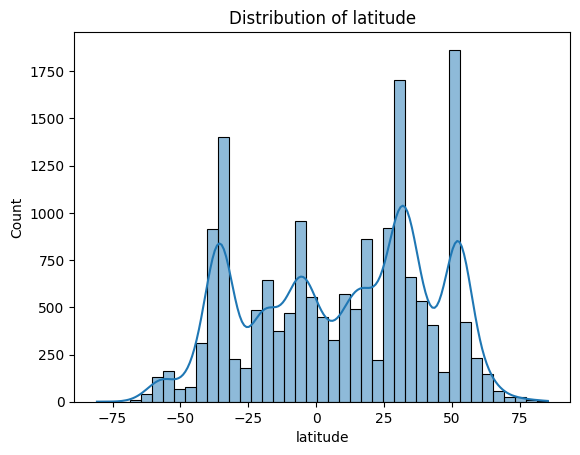

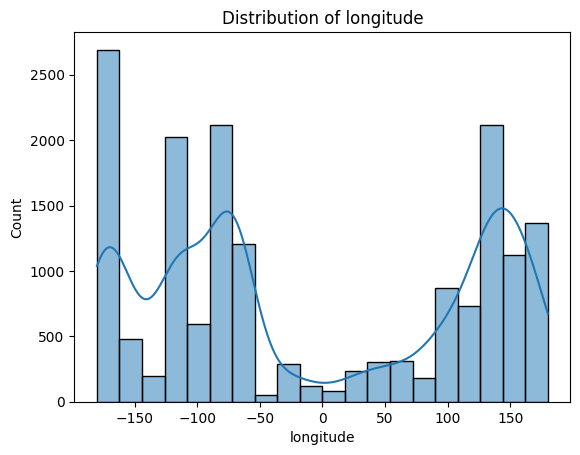

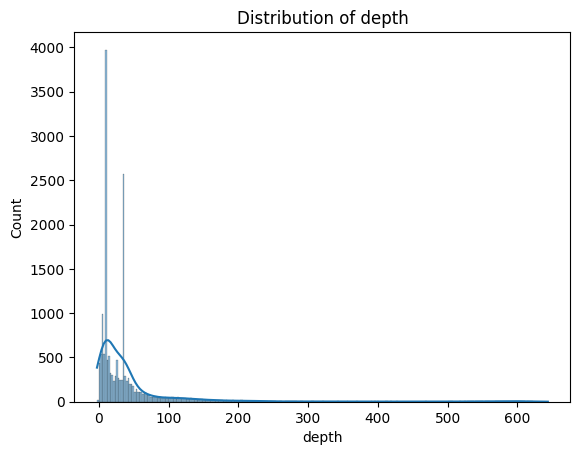

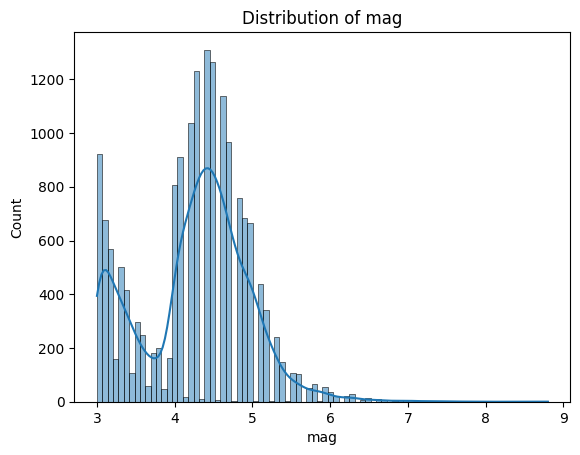

In [15]:
num_cols = Earthquake.select_dtypes(include=np.number).columns

for col in num_cols[:4]:
    sns.histplot(Earthquake[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

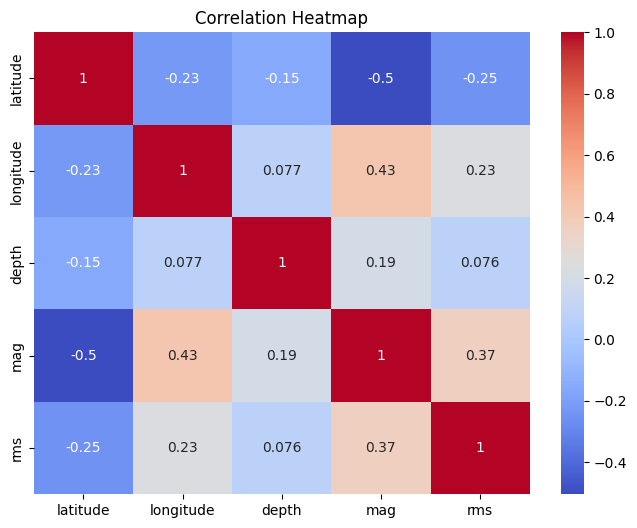

In [16]:
corr = Earthquake[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **Normalize Data**

In [17]:
Earthquake_numeric = Earthquake.drop(columns=['time'])

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(Earthquake_numeric)

# **Time-Series Sequences**

In [18]:
def create_sequences(data, time_steps=10):
    X = []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
    return np.array(X)

TIME_STEPS = 10
X = create_sequences(data_scaled, TIME_STEPS)

print("Shape of data:", X.shape)

Shape of data: (17086, 10, 5)


# **Train-Test Split**

In [19]:
X_train, X_test = train_test_split(X, test_size=0.2, shuffle=False)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (13668, 10, 5)
Test shape: (3418, 10, 5)


# **Deep Learning Model**

In [20]:
timesteps = X_train.shape[1]
features = X_train.shape[2]

inputs = Input(shape=(timesteps, features))

# Encoder
encoded = LSTM(64, activation='relu', return_sequences=True)(inputs)
encoded = LSTM(32, activation='relu')(encoded)

# Bottleneck
decoded = RepeatVector(timesteps)(encoded)

# Decoder
decoded = LSTM(32, activation='relu', return_sequences=True)(decoded)
decoded = LSTM(64, activation='relu', return_sequences=True)(decoded)

outputs = TimeDistributed(Dense(features))(decoded)

model = Model(inputs, outputs)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 10, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 5)          │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,813 (249.27 KB)

 Trainable params: 63,813 (249.27 KB)

 Non-trainable params: 0 (0.00 B)

# **Hyperparameter using Model Training**

In [21]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

history = model.fit(
    X_train, X_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - loss: 0.0394 - val_loss: 0.0334
Epoch 2/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0272 - val_loss: 0.0307
Epoch 3/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0248 - val_loss: 0.0287
Epoch 4/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0231 - val_loss: 0.0268
Epoch 5/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0218 - val_loss: 0.0252
Epoch 6/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0203 - val_loss: 0.0238
Epoch 7/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0193 - val_loss: 0.0225
Epoch 8/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0182 - val_loss: 0.0215
Epoch 9/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0172 - val_loss: 0.0203
Epoch 10/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0165 - val_loss: 0.0198


In [22]:
model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')

history2 = model.fit(
    X_train, X_train,
    epochs=10,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
769/769 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 0.0154 - val_loss: 0.0182
Epoch 2/10
769/769 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0145 - val_loss: 0.0178
Epoch 3/10
769/769 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0135 - val_loss: 0.0159
Epoch 4/10
769/769 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0125 - val_loss: 0.0152
Epoch 5/10
769/769 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0117 - val_loss: 0.0142
Epoch 6/10
769/769 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0113 - val_loss: 0.0138
Epoch 7/10
769/769 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0108 - val_loss: 0.0129
Epoch 8/10
769/769 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0105 - val_loss: 0.0131
Epoch 9/10
769/769 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0102 - val_loss: 0.0126
Epoch 10/10
769/769 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0098 - val_loss: 0.0120


#**Hyperparameter Tuning Comparison**

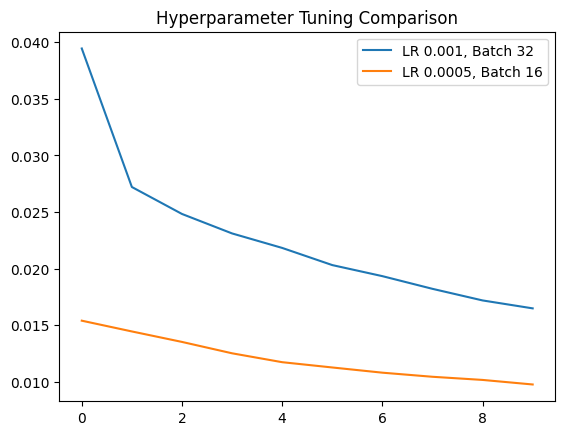

In [23]:
plt.plot(history.history['loss'], label='LR 0.001, Batch 32')
plt.plot(history2.history['loss'], label='LR 0.0005, Batch 16')

plt.legend()
plt.title("Hyperparameter Tuning Comparison")
plt.show()

# **Plot Training Performance**

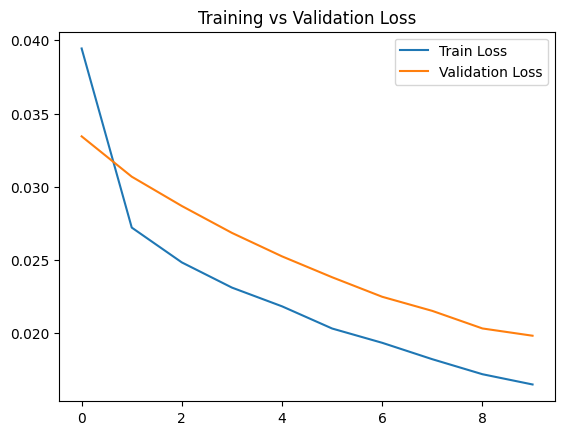

In [24]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# **Anomaly Detection**

In [25]:
X_pred = model.predict(X_test)

mse = np.mean(np.power(X_test - X_pred, 2), axis=(1,2))

threshold = np.percentile(mse, 95)

anomalies = mse > threshold

print("Threshold:", threshold)
print("Total anomalies detected:", np.sum(anomalies))

print("\nReconstruction Error Stats:")
print("Mean:", np.mean(mse))
print("Std Dev:", np.std(mse))
print("Max:", np.max(mse))

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
Threshold: 0.02229611830311369
Total anomalies detected: 171

Reconstruction Error Stats:
Mean: 0.00976160071948575
Std Dev: 0.006208810119466586
Max: 0.05615021682896306


# **Visualize Anomalies**

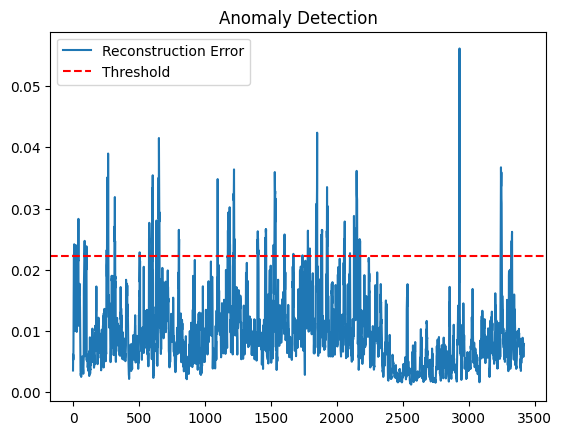

In [26]:
plt.figure()

plt.plot(mse, label='Reconstruction Error')
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')

plt.title("Anomaly Detection")
plt.legend()

plt.show()

# **Anomalies on magnitude**

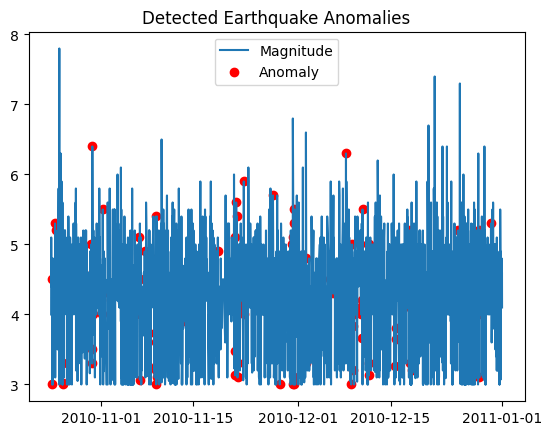

In [27]:
# Align anomaly index with original data
test_index = Earthquake.iloc[-len(mse):].index

Earthquake_test = Earthquake.loc[test_index].copy()
Earthquake_test['anomaly'] = anomalies

plt.figure()

plt.plot(Earthquake_test['time'], Earthquake_test['mag'], label='Magnitude')
plt.scatter(Earthquake_test[Earthquake_test['anomaly']]['time'],
            Earthquake_test[Earthquake_test['anomaly']]['mag'],
            color='red', label='Anomaly')

plt.legend()
plt.title("Detected Earthquake Anomalies")

plt.show()